# Nonparametric Correlation: Spearman and Kendall's τ

## Overview

Nonparametric correlation coefficients measure **monotonic** association between two variables without assuming a linear relationship or normally distributed data.

| Coefficient | Formula basis | Null | Range | Use Case |
|---|---|---|---|---|
| **Pearson r** | Raw values | No linear association | -1 to 1 | Continuous, approximately normal, linear relationship |
| **Spearman ρ** | Ranks of values | No monotonic association | -1 to 1 | Non-normal, ordinal, or monotonic non-linear relationship |
| **Kendall τ** | Concordant/discordant pairs | No monotonic association | -1 to 1 | Small samples; ties common; more interpretable probability statement |

**Kendall τ vs. Spearman ρ:**  
Kendall τ is the probability that a randomly chosen pair of observations is concordant minus the probability it is discordant. This makes it directly interpretable as a probability statement. Spearman ρ is more commonly reported in ecology because it is directly analogous to Pearson r on ranks, but Kendall τ is preferred for small samples and when ties are present.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Correlation between water quality index and invertebrate richness; correlation between two ordinal habitat quality scores from different assessors |
| **Healthcare** | Correlation between patient-reported pain scale and clinician-assessed severity; correlation between biomarker and ordinal disease stage |
| **Finance** | Correlation between analyst rankings and subsequent returns; monotonic relationship between credit rating and default rate |

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(ggpubr)       # stat_cor() for adding correlation to plots
library(corrplot)     # correlation matrix visualization
library(psych)        # corr.test() — correlations + p-values for matrices
                      # replaces Hmisc::rcorr() — same functionality, no xfun dependency

set.seed(42)

## Data

In [4]:
n <- 50

# ── Continuous monotonic but non-linear relationship ─────────────────────────
site_data <- tibble(
  water_quality = runif(n, 1, 10),
  # Non-linear: richness grows quickly at first, levels off
  richness      = round(20 * (1 - exp(-0.35 * water_quality)) + rnorm(n, 0, 2)),
  pH            = 5.5 + 0.35 * water_quality + rnorm(n, 0, 0.5),
  turbidity     = 15 - 1.2 * water_quality + rnorm(n, 0, 1.5),
  nitrate       = 5 - 0.4 * water_quality + rnorm(n, 0, 0.8),
  # Ordinal assessor score (1–5)
  quality_score = as.integer(cut(water_quality + rnorm(n, 0, 0.5),
                                  breaks = quantile(water_quality, probs = 0:5/5),
                                  labels = 1:5, include.lowest = TRUE))
) %>%
  mutate(richness = pmax(richness, 0L))

glimpse(site_data)

Rows: 50
Columns: 6
$ water_quality <dbl> 9.233254, 9.433679, 3.575256, 8.474029, 6.775710, 5.6718…
$ richness      <dbl> 18, 19, 11, 20, 17, 18, 20, 13, 17, 19, 13, 17, 18, 9, 1…
$ pH            <dbl> 9.022137, 9.185877, 6.983223, 8.023022, 7.321608, 8.2415…
$ turbidity     <dbl> 3.277706, 2.759078, 7.672676, 2.994044, 7.138423, 9.0451…
$ nitrate       <dbl> 1.18607745, 0.06732281, 4.08430463, 1.99694364, 2.284631…
$ quality_score <int> 4, 5, 1, 4, 3, 2, 4, 1, 3, 3, 2, 4, 5, 1, 2, 4, NA, 1, 3…


---

## Single Pair: Spearman and Kendall

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


method,estimate,p_value,statistic
<chr>,<dbl>,<dbl>,<dbl>
Pearson r,0.8408,0,10.7624
Spearman ρ,0.7745,0,4696.5273
Kendall τ,0.6124,0,6.0465


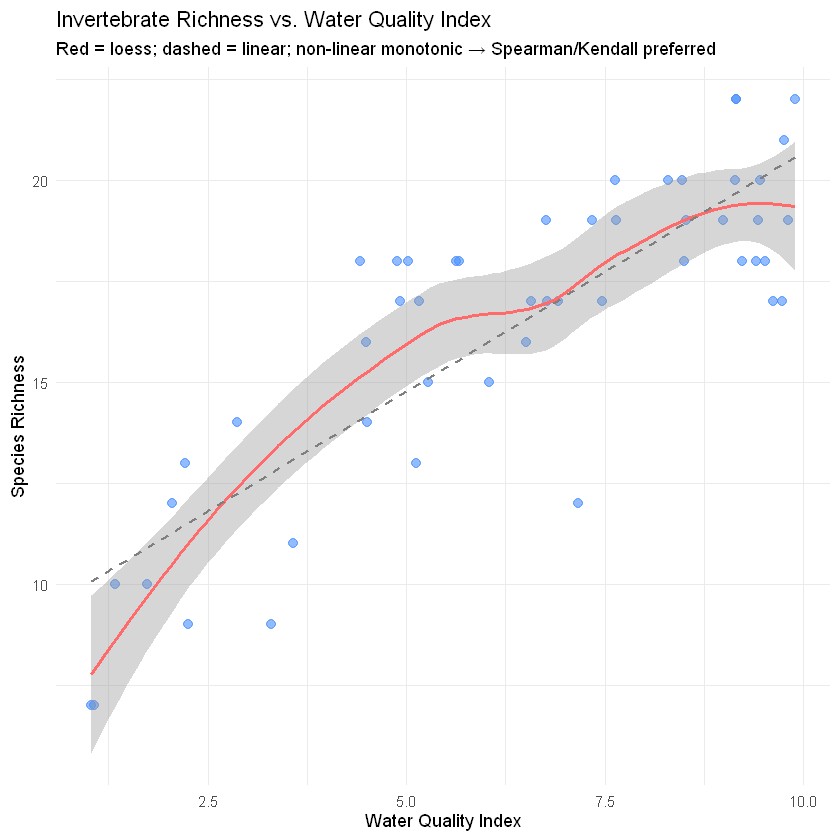

In [5]:
# ── Scatter plot ──────────────────────────────────────────────────────────────
ggplot(site_data, aes(x = water_quality, y = richness)) +
  geom_point(alpha = 0.6, color = "#4a8fff", size = 2.5) +
  geom_smooth(method = "loess", se = TRUE, color = "#ff6b6b", linewidth = 1) +
  geom_smooth(method = "lm",    se = FALSE, color = "gray50",
              linewidth = 0.7, linetype = "dashed") +
  labs(
    title    = "Invertebrate Richness vs. Water Quality Index",
    subtitle = "Red = loess; dashed = linear; non-linear monotonic → Spearman/Kendall preferred",
    x = "Water Quality Index", y = "Species Richness"
  ) +
  theme_minimal()

# ── Pearson (for comparison) ──────────────────────────────────────────────────
pearson <- cor.test(site_data$water_quality, site_data$richness, method = "pearson")

# ── Spearman ρ ────────────────────────────────────────────────────────────────
spearman <- cor.test(site_data$water_quality, site_data$richness,
                     method = "spearman", exact = FALSE)

# ── Kendall τ ─────────────────────────────────────────────────────────────────
kendall <- cor.test(site_data$water_quality, site_data$richness,
                    method = "kendall", exact = FALSE)

tibble(
  method    = c("Pearson r", "Spearman ρ", "Kendall τ"),
  estimate  = c(pearson$estimate,  spearman$estimate,  kendall$estimate),
  p_value   = c(pearson$p.value,   spearman$p.value,   kendall$p.value),
  statistic = c(pearson$statistic, spearman$statistic, kendall$statistic)
) %>%
  mutate(across(where(is.numeric), ~ round(.x, 4)))

# Note: Spearman ρ > Pearson r here — the monotonic association is captured
# better by ranks than by the linear assumption
# Kendall τ is numerically smaller than Spearman ρ but not directly comparable
# — they measure slightly different things

---

## Correlation with Ordinal Variables

Kendall τ is preferred when one or both variables are ordinal — it handles ties correctly and has a direct probability interpretation.

Kendall τ (ordinal score ~ richness): τ = 0.6608, p = 0.0000


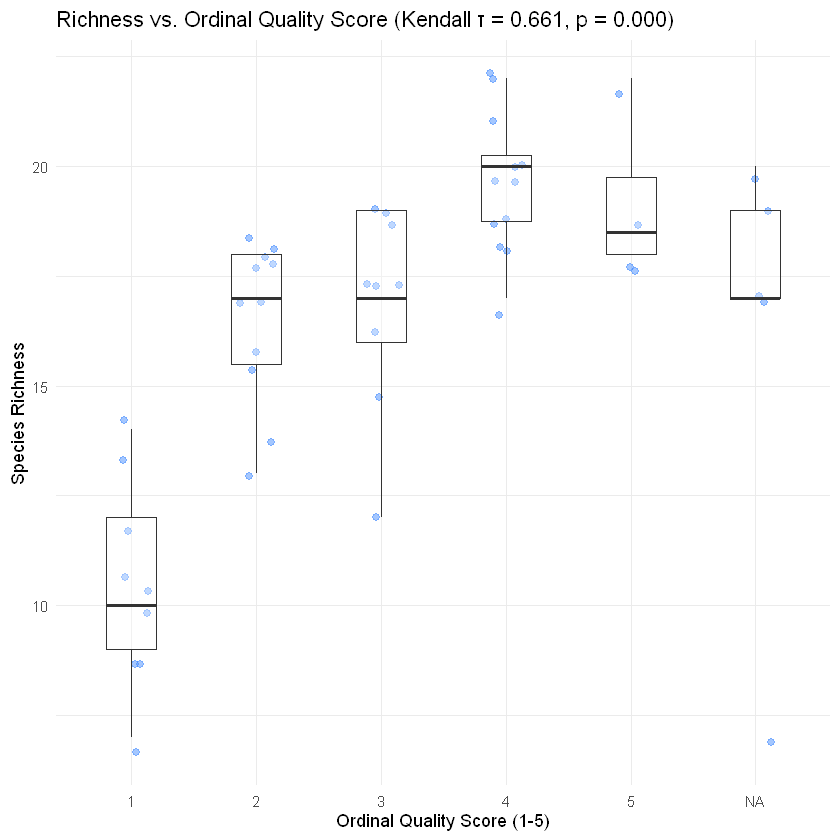

In [6]:
# ── Ordinal quality score vs. continuous richness ─────────────────────────────
kendall_ord <- cor.test(site_data$quality_score, site_data$richness,
                         method = "kendall", exact = FALSE)
cat(sprintf("Kendall τ (ordinal score ~ richness): τ = %.4f, p = %.4f\n",
            kendall_ord$estimate, kendall_ord$p.value))

# Interpretation: τ = 0.4 means:
# A randomly chosen pair of sites where quality_score is higher for site A
# than site B is 40% more likely than not to also have higher richness at A

# ── Jittered scatter for ordinal variable ─────────────────────────────────────
ggplot(site_data, aes(x = factor(quality_score), y = richness)) +
  geom_jitter(width = 0.15, alpha = 0.5, color = "#4a8fff", size = 2) +
  geom_boxplot(alpha = 0.3, outlier.shape = NA, width = 0.4) +
  labs(
    title = sprintf("Richness vs. Ordinal Quality Score (Kendall τ = %.3f, p = %.3f)",
                    kendall_ord$estimate, kendall_ord$p.value),
    x = "Ordinal Quality Score (1-5)", y = "Species Richness"
  ) +
  theme_minimal()

---

## Correlation Matrix

Spearman correlation matrix:
              richness water_quality     pH turbidity nitrate
richness         1.000         0.774  0.728    -0.725  -0.658
water_quality    0.774         1.000  0.866    -0.899  -0.804
pH               0.728         0.866  1.000    -0.785  -0.731
turbidity       -0.725        -0.899 -0.785     1.000   0.794
nitrate         -0.658        -0.804 -0.731     0.794   1.000



p-value matrix:
              richness water_quality pH turbidity nitrate
richness             0             0  0         0       0
water_quality        0             0  0         0       0
pH                   0             0  0         0       0
turbidity            0             0  0         0       0
nitrate              0             0  0         0       0

10 pairs tested; BH-corrected p-values:
 [1] 0 0 0 0 0 0 0 0 0 0


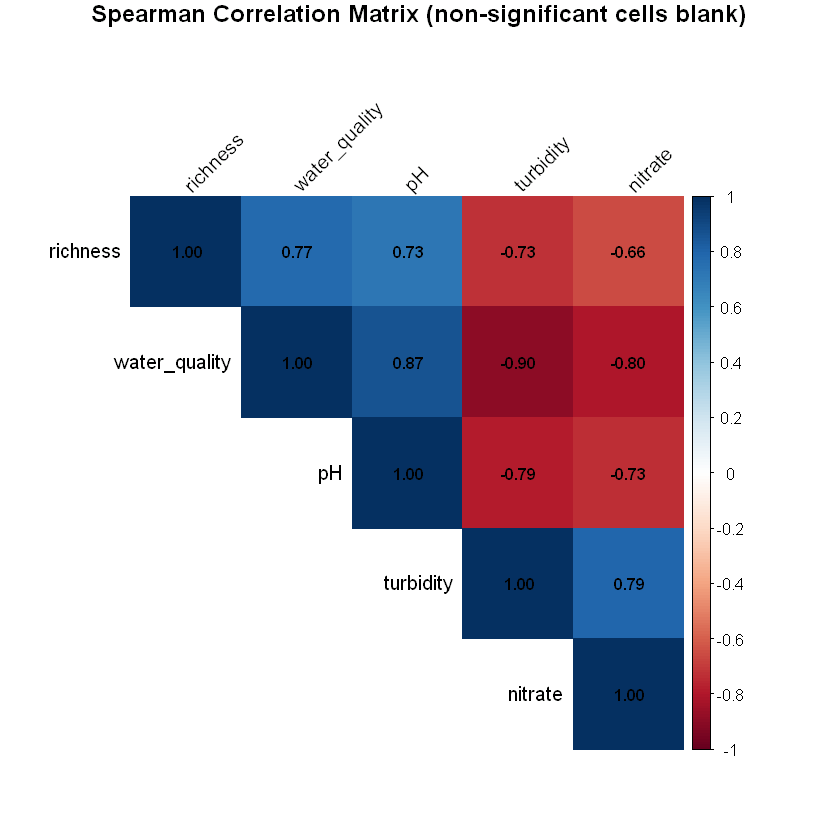

In [8]:
# ── Compute Spearman correlation matrix with p-values ─────────────────────────
vars <- site_data %>%
  dplyr::select(richness, water_quality, pH, turbidity, nitrate) %>%
  as.matrix()

# psych::corr.test() replaces Hmisc::rcorr() — same info, no xfun dependency
corr_result <- psych::corr.test(vars, method = "spearman")
cat("Spearman correlation matrix:\n")
print(round(corr_result$r, 3))
cat("\np-value matrix:\n")
print(round(corr_result$p, 4))

# ── Correct p-values for multiple comparisons ─────────────────────────────────
# psych returns lower triangle adjusted, upper triangle raw — symmetrize first
p_mat <- corr_result$p
p_mat_sym <- pmax(p_mat, t(p_mat))   # symmetrize: take max of [i,j] and [j,i]

p_vals_upper <- p_mat_sym[upper.tri(p_mat_sym)]
p_vals_adj   <- p.adjust(p_vals_upper, method = "BH")
cat(sprintf("\n%d pairs tested; BH-corrected p-values:\n",
            length(p_vals_upper)))
print(round(p_vals_adj, 4))

# ── Correlation plot ──────────────────────────────────────────────────────────
corrplot::corrplot(
  corr_result$r,
  method      = "color",
  type        = "upper",
  addCoef.col = "black",
  number.cex  = 0.8,
  tl.col      = "black",
  tl.srt      = 45,
  p.mat       = p_mat_sym,
  sig.level   = 0.05,
  insig       = "blank",
  title       = "Spearman Correlation Matrix (non-significant cells blank)",
  mar         = c(0, 0, 1, 0)
)

---

## Reporting Results

In [9]:
cat(sprintf("Spearman ρ = %.4f, S = %.1f, p = %.4f\n",
            spearman$estimate, spearman$statistic, spearman$p.value))
cat(sprintf("Kendall τ  = %.4f, z = %.4f, p = %.4f\n",
            kendall$estimate, kendall$statistic, kendall$p.value))

# Standard reporting format:
# "Invertebrate species richness was significantly positively correlated
#  with water quality index (Spearman ρ = .XX, p = .XXX), indicating
#  a monotonic association between water quality and community diversity.
#  The relationship was non-linear (loess vs. linear fit comparison),
#  justifying the use of rank correlation over Pearson r."
#
# For ordinal:
# "Kendall τ was used to assess correlation between ordinal quality
#  score and species richness (τ = .XX, z = X.XX, p = .XXX)."
#
# For matrices: always state the correction method used for p-values.

Spearman ρ = 0.7745, S = 4696.5, p = 0.0000
Kendall τ  = 0.6124, z = 6.0465, p = 0.0000


---

## Common Pitfalls

**1. Treating Spearman ρ and Pearson r as directly comparable**  
Spearman ρ measures monotonic association; Pearson r measures linear association. A high Spearman but lower Pearson suggests the relationship is monotonic but non-linear — that's informative, not a problem.

**2. Not correcting for multiple comparisons in a correlation matrix**  
Testing all pairs in a 5-variable matrix produces 10 simultaneous tests. Apply BH correction to the upper triangle p-values before reporting.

**3. Confusing Kendall τ and Spearman ρ magnitude**  
Kendall τ values are always numerically smaller than Spearman ρ for the same data. They are not on the same scale and should not be compared directly — each measures a slightly different property of the association.

**4. Using Spearman correlation as a substitute for regression**  
Correlation quantifies association strength and direction — it does not model a predictive relationship. If you want to predict one variable from another, use regression (possibly nonparametric, see `permutation_tests.ipynb`).

**5. Reporting only the correlation coefficient without a confidence interval**  
The `cor.test()` function does not return CIs for Spearman or Kendall. Use bootstrapping or the `DescTools::SpearmanRho()` function with `conf.level` to obtain them.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*